# Обучение моделей предсказания выкупа заказов

**Структура:**
1. Загрузка подготовленных данных
2. Модель повторных клиентов (single-feature LogReg, buyout 97%+)
3. Кодирование признаков для новых клиентов
4. Кросс-валидация модели новых клиентов
5. Финальная модель + метрики + графики
6. Анализ важности признаков
7. Сохранение весов + валидация через `BuyoutPredictor`

In [1]:
import pandas as pd
import numpy as np
import pickle
import os
import joblib
import warnings
import matplotlib.pyplot as plt
from collections import defaultdict

from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve, roc_curve,
    average_precision_score, balanced_accuracy_score, matthews_corrcoef
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)

GREEN = '#2ecc71'
RED = '#e74c3c'

## 1. Загрузка подготовленных данных

In [2]:
with open('processed_data.pkl', 'rb') as f:
    art = pickle.load(f)

new_train = art['new_train']
new_test = art['new_test']
new_val = art['new_val']
ret_train = art['ret_train']
ret_test = art['ret_test']
ret_val = art['ret_val']
train_df = art['train_df']
test_df = art['test_df']
val_df = art['val_df']
russia_cities = art['russia_cities']
manager_deal_count_map = art['manager_deal_count_map']
mgr_group_map = art.get('mgr_group_map', {})
big_city_map = art.get('big_city_map', {})

cat_cols = art['cat_cols']
num_cols = art['num_cols']
bin_cols = art['bin_cols']
geo_cols = art['geo_cols']
te_cat_cols = art['te_cat_cols']
all_feature_cols = art['all_feature_cols']
cat_drop_first = art.get('cat_drop_first', {})

# Per-feature alpha для target encoding (из features.yaml)
import yaml
with open('features.yaml', encoding='utf-8') as f:
    _feat_config = yaml.safe_load(f)
TE_ALPHA_PER_FEATURE = {}
for fname, fspec in _feat_config.get('features', {}).items():
    if 'alpha' in fspec:
        TE_ALPHA_PER_FEATURE[fname] = fspec['alpha']

target = 'buyout_flag'

print('=== Размеры выборок ===')
print(f'Новые клиенты:    train={len(new_train)}, test={len(new_test)}, val={len(new_val)}')
print(f'Повторные:        train={len(ret_train)}, test={len(ret_test)}, val={len(ret_val)}')
print(f'Всего:            train={len(train_df)}, test={len(test_df)}, val={len(val_df)}')
print(f'\nBuyout rate (new train): {new_train[target].mean():.4f}')
print(f'Buyout rate (ret train): {ret_train[target].mean():.4f}')
print(f'\nПризнаки ({len(all_feature_cols)}):')
print(f'  cat_cols ({len(cat_cols)}): {cat_cols}')
print(f'  num_cols ({len(num_cols)}): {num_cols}')
print(f'  bin_cols ({len(bin_cols)}): {bin_cols}')
print(f'  geo_cols ({len(geo_cols)}): {geo_cols}')
print(f'  te_cat_cols ({len(te_cat_cols)}): {te_cat_cols}')
print(f'  cat_drop_first: { {k: v for k, v in cat_drop_first.items()} }')
print(f'\nTE alpha per feature: {TE_ALPHA_PER_FEATURE}')

=== Размеры выборок ===
Новые клиенты:    train=2447, test=816, val=816
Повторные:        train=8332, test=2778, val=2777
Всего:            train=10779, test=3594, val=3593

Buyout rate (new train): 0.3249
Buyout rate (ret train): 0.9762

Признаки (20):
  cat_cols (15): ['lead_Вид оплаты', 'lead_Тариф Доставки', 'lead_Квалификация лида', 'lead_Категория и варианты выбора', 'lead_Модель телефона', 'lead_responsible_user_id', 'lead_Проблема', 'lead_group_id', 'lead_Служба доставки', 'price_bin', 'sale_weekday', 'cart_bin', 'manager_bin', 'mgr_group', 'delta_bin']
  num_cols (0): []
  bin_cols (3): ['has_future_purchase', 'is_paid_traffic', 'is_big_city']
  geo_cols (2): ['city_clean', 'contact_region']
  te_cat_cols (0): []
  cat_drop_first: {'lead_Вид оплаты': False, 'lead_Тариф Доставки': False, 'lead_Квалификация лида': False, 'lead_Категория и варианты выбора': False, 'lead_Модель телефона': False, 'lead_responsible_user_id': False, 'lead_Проблема': False, 'lead_group_id': False, 'le

## 2. Модель повторных клиентов

Buyout rate по числу прошлых заказов:
             buyout_rate  count
deals_group                    
1                 0.9771  10196
2                 0.9672   1918
3                 0.9721    645
4                 0.9892    372
5                 0.9815    216
6+                0.9852    540

Общий buyout rate повторных: 0.9762


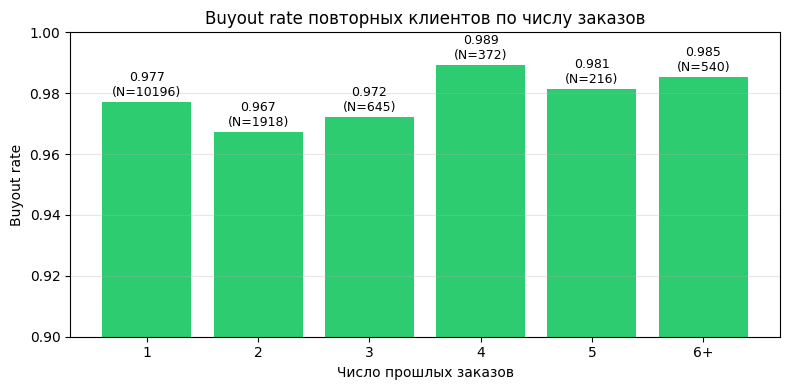

In [3]:
# Buyout rate по числу прошлых заказов
ret_all = pd.concat([ret_train, ret_test, ret_val])
ret_all['deals_group'] = ret_all['contact_Число сделок'].clip(upper=6).astype(int).astype(str)
ret_all.loc[ret_all['contact_Число сделок'] >= 6, 'deals_group'] = '6+'

stats = ret_all.groupby('deals_group')[target].agg(['mean', 'count']).sort_index()
stats.columns = ['buyout_rate', 'count']

print('Buyout rate по числу прошлых заказов:')
print(stats.to_string(float_format='%.4f'))
print(f'\nОбщий buyout rate повторных: {ret_all[target].mean():.4f}')

fig, ax = plt.subplots(figsize=(8, 4))
colors_bar = [GREEN if r >= 0.95 else '#f39c12' for r in stats['buyout_rate']]
ax.bar(stats.index, stats['buyout_rate'], color=colors_bar)
ax.set_xlabel('Число прошлых заказов')
ax.set_ylabel('Buyout rate')
ax.set_title('Buyout rate повторных клиентов по числу заказов')
ax.set_ylim(0.9, 1.0)
ax.grid(axis='y', alpha=0.3)
for i, (idx, row) in enumerate(stats.iterrows()):
    ax.text(i, row['buyout_rate'] + 0.002, f'{row["buyout_rate"]:.3f}\n(N={int(row["count"])})',
            ha='center', fontsize=9)
plt.tight_layout(); plt.show()

In [4]:
FEAT_RET = 'contact_Число сделок'

train_df_1f = train_df.copy()
test_df_1f = test_df.copy()
train_df_1f[FEAT_RET] = train_df_1f[FEAT_RET].fillna(0)
test_df_1f[FEAT_RET] = test_df_1f[FEAT_RET].fillna(0)

X_1f_train = train_df_1f[[FEAT_RET]].values
y_1f_train = train_df_1f[target].values
X_1f_test = test_df_1f[[FEAT_RET]].values
y_1f_test = test_df_1f[target].values

scaler_ret = StandardScaler()
X_1f_train_sc = scaler_ret.fit_transform(X_1f_train)
X_1f_test_sc = scaler_ret.transform(X_1f_test)

model_ret = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_ret.fit(X_1f_train_sc, y_1f_train)

X_ret_test_sc = scaler_ret.transform(ret_test[[FEAT_RET]].values)
p_ret_test = model_ret.predict_proba(X_ret_test_sc)[:, 1]
y_ret_pred = (p_ret_test >= 0.5).astype(int)
y_ret_test_vals = ret_test[target].values

print('=' * 50)
print('Модель повторных клиентов (single-feature LogReg)')
print('=' * 50)
print(f'  Коэффициент: {model_ret.coef_[0][0]:.4f}')
print(f'  Intercept:   {model_ret.intercept_[0]:.4f}')
print(f'  Odds Ratio:  {np.exp(model_ret.coef_[0][0]):.2f}')
print()
print('  Метрики на повторных клиентах (test):')
print(f'    Accuracy:  {accuracy_score(y_ret_test_vals, y_ret_pred):.4f}')
print(f'    F1:        {f1_score(y_ret_test_vals, y_ret_pred):.4f}')
print(f'    ROC-AUC:   {roc_auc_score(y_ret_test_vals, p_ret_test):.4f}')
print(f'    Precision: {precision_score(y_ret_test_vals, y_ret_pred):.4f}')
print(f'    Recall:    {recall_score(y_ret_test_vals, y_ret_pred):.4f}')
print('=' * 50)

Модель повторных клиентов (single-feature LogReg)
  Коэффициент: 5.3147
  Intercept:   2.2038
  Odds Ratio:  203.31

  Метрики на повторных клиентах (test):
    Accuracy:  0.9762
    F1:        0.9880
    ROC-AUC:   0.4643
    Precision: 0.9762
    Recall:    1.0000


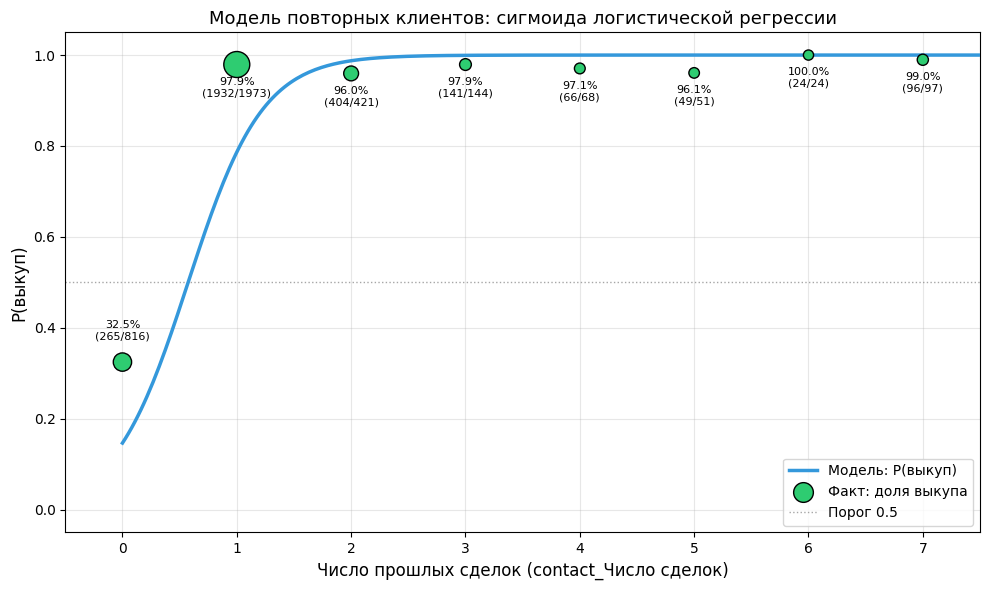

In [5]:
# Сигмоида модели + фактические данные
x_range = np.linspace(0, 8, 300)
x_range_sc = scaler_ret.transform(x_range.reshape(-1, 1))
p_sigmoid = model_ret.predict_proba(x_range_sc)[:, 1]

test_1f = test_df.copy()
test_1f[FEAT_RET] = test_1f[FEAT_RET].fillna(0)
test_1f['deals_int'] = test_1f[FEAT_RET].clip(upper=7).astype(int)

actual_stats = test_1f.groupby('deals_int')[target].agg(['mean', 'sum', 'count'])
actual_stats.columns = ['buyout_rate', 'n_buyout', 'n_total']

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(x_range, p_sigmoid, color='#3498db', lw=2.5, label='Модель: P(выкуп)', zorder=3)

sizes = (actual_stats['n_total'] / actual_stats['n_total'].max()) * 300 + 50
ax.scatter(actual_stats.index, actual_stats['buyout_rate'],
           s=sizes, color=GREEN, edgecolor='black', linewidth=1,
           zorder=4, label='Факт: доля выкупа')

for deals, row in actual_stats.iterrows():
    offset_y = -0.07 if row['buyout_rate'] > 0.5 else 0.05
    ax.annotate(f"{row['buyout_rate']:.1%}\n({int(row['n_buyout'])}/{int(row['n_total'])})",
                xy=(deals, row['buyout_rate']),
                xytext=(deals, row['buyout_rate'] + offset_y),
                ha='center', fontsize=8)

ax.axhline(0.5, color='gray', linestyle=':', linewidth=1, alpha=0.7, label='Порог 0.5')
ax.set_xlabel('Число прошлых сделок (contact_Число сделок)', fontsize=12)
ax.set_ylabel('P(выкуп)', fontsize=12)
ax.set_title('Модель повторных клиентов: сигмоида логистической регрессии', fontsize=13)
ax.set_xlim(-0.5, 7.5); ax.set_ylim(-0.05, 1.05)
ax.set_xticks(range(8))
ax.legend(loc='lower right', fontsize=10)
ax.grid(axis='both', alpha=0.3)
plt.tight_layout(); plt.show()

---

## 3. Кодирование признаков для новых клиентов

Для модели новых клиентов применяем следующее кодирование:
- **One-hot encoding** (15 признаков) — все категориальные, включая `lead_responsible_user_id` (26 менеджеров, L1 обнуляет незначимых) и инженерные (`mgr_group`, `price_bin`, `cart_bin`, `manager_bin`, `delta_bin`, `sale_weekday`)
- **Passthrough** для бинарных признаков (`has_future_purchase`, `is_paid_traffic`, `is_big_city`)
- **K-fold smoothed target encoding** для гео-признаков: `city_clean` (alpha=10) и `contact_region` (alpha=50)

TE со сглаживанием: `te = (count * mean + alpha * global_mean) / (count + alpha)`.
Alpha для каждого TE-признака задаётся индивидуально в `features.yaml`.

In [6]:
def kfold_target_encoding(X, y, col, n_splits=5, alpha=10, random_state=42):
    """Out-of-fold target encoding с additive smoothing."""
    global_mean = float(y.mean())
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    te = np.full(len(X), global_mean)
    for train_idx, val_idx in kf.split(X):
        stats = X.iloc[train_idx].join(y.iloc[train_idx].rename('target')).groupby(col)['target'].agg(['mean', 'count'])
        stats['te'] = (stats['mean'] * stats['count'] + global_mean * alpha) / (stats['count'] + alpha)
        te[val_idx] = X.iloc[val_idx][col].map(stats['te']).fillna(global_mean).values
    return te


def encode_fold(X_tr, y_tr, X_va, cc=None, nc=None, bc=None, gc=None, tc=None,
                alpha=10, drop_first_map=None, alpha_per_feature=None):
    """Полный пайплайн кодирования.

    drop_first_map: dict[col, bool] — per-column drop_first для one-hot.
    alpha_per_feature: dict[col, int] — per-feature alpha для target encoding.
    """
    cc = cat_cols if cc is None else cc
    nc = num_cols if nc is None else nc
    bc = bin_cols if bc is None else bc
    gc = geo_cols if gc is None else gc
    tc = te_cat_cols if tc is None else tc
    dfm = drop_first_map if drop_first_map is not None else cat_drop_first
    apf = alpha_per_feature or {}

    parts_tr, parts_va = [], []

    # One-hot (per-column drop_first; NaN → all-zeros automatically)
    if cc:
        oh_tr, oh_va = [], []
        for col in cc:
            df_flag = dfm.get(col, False)
            d_tr = pd.get_dummies(X_tr[[col]], drop_first=df_flag)
            d_va = pd.get_dummies(X_va[[col]], drop_first=df_flag)
            oh_tr.append(d_tr)
            oh_va.append(d_va)
        c_tr = pd.concat(oh_tr, axis=1)
        c_va = pd.concat(oh_va, axis=1)
        c_tr, c_va = c_tr.align(c_va, join='left', axis=1, fill_value=0)
        parts_tr.append(c_tr); parts_va.append(c_va)

    # StandardScaler (только если есть числовые признаки)
    sc = None
    if nc:
        sc = StandardScaler().fit(X_tr[nc])
        parts_tr.append(pd.DataFrame(sc.transform(X_tr[nc]), columns=nc, index=X_tr.index))
        parts_va.append(pd.DataFrame(sc.transform(X_va[nc]), columns=nc, index=X_va.index))

    # Бинарные
    if bc:
        parts_tr.append(X_tr[bc].reset_index(drop=True).set_index(X_tr.index))
        parts_va.append(X_va[bc].reset_index(drop=True).set_index(X_va.index))

    # Target encoding (per-feature alpha)
    gm = float(y_tr.mean())
    te_cols = gc + tc
    for col_te in te_cols:
        a = apf.get(col_te, alpha)
        te_name = col_te + '_te'
        te_tr = kfold_target_encoding(X_tr, y_tr, col_te, alpha=a)
        parts_tr.append(pd.DataFrame({te_name: te_tr}, index=X_tr.index))
        stats = X_tr.join(y_tr.rename('target')).groupby(col_te)['target'].agg(['mean', 'count'])
        te_map = (stats['mean'] * stats['count'] + gm * a) / (stats['count'] + a)
        parts_va.append(pd.DataFrame({te_name: X_va[col_te].map(te_map).fillna(gm).values}, index=X_va.index))

    X_tr_enc = pd.concat(parts_tr, axis=1).fillna(0)
    X_va_enc = pd.concat(parts_va, axis=1).fillna(0)
    return X_tr_enc, X_va_enc, sc

print(f'Функции кодирования определены.')

Функции кодирования определены.


## 4. Кросс-валидация модели новых клиентов

5-fold stratified CV. Конфигурация:
- **LogReg:** L1-регуляризация, C=4, solver=liblinear, `class_weight='balanced'`
- **Target encoding:** per-feature alpha из `features.yaml` (city_clean=10, contact_region=50)

L1-регуляризация выбрана для автоматического отбора признаков: обнуляет коэффициенты незначимых dummy-переменных (из 85+ encoded-столбцов обычно остаётся ~60 ненулевых).

In [7]:
C = 4

In [8]:
X_new_train = new_train[all_feature_cols].copy()
y_new_train = new_train[target].copy()
X_new_test = new_test[all_feature_cols].copy()
y_new_test = new_test[target].copy()
X_new_val = new_val[all_feature_cols].copy()
y_new_val = new_val[target].copy()

TE_ALPHA = 10  # fallback alpha

# 5-fold stratified cross-validation
cv_aucs = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_new_train, y_new_train)):
    X_tr = X_new_train.iloc[tr_idx]
    y_tr = y_new_train.iloc[tr_idx]
    X_va = X_new_train.iloc[va_idx]
    y_va = y_new_train.iloc[va_idx]

    X_tr_enc, X_va_enc, _ = encode_fold(X_tr, y_tr, X_va, alpha=TE_ALPHA,
                                         alpha_per_feature=TE_ALPHA_PER_FEATURE)

    m = LogisticRegression(C=C, penalty='l1', max_iter=2000,
                           class_weight='balanced', random_state=42, solver='liblinear')
    m.fit(X_tr_enc, y_tr)

    auc = roc_auc_score(y_va, m.predict_proba(X_va_enc)[:, 1])
    cv_aucs.append(auc)
    print(f'  Fold {fold+1}: AUC = {auc:.4f}')

print(f'\nCV AUC: {np.mean(cv_aucs):.4f} ± {np.std(cv_aucs):.4f}')

  Fold 1: AUC = 0.8555


  Fold 2: AUC = 0.8627


  Fold 3: AUC = 0.8352


  Fold 4: AUC = 0.8584


  Fold 5: AUC = 0.8778

CV AUC: 0.8579 ± 0.0137


## 5. Финальная модель новых клиентов

In [9]:
X_train_enc, X_test_enc, scaler_new = encode_fold(
    X_new_train, y_new_train, X_new_test, alpha=TE_ALPHA,
    alpha_per_feature=TE_ALPHA_PER_FEATURE)
_, X_val_enc, _ = encode_fold(
    X_new_train, y_new_train, X_new_val, alpha=TE_ALPHA,
    alpha_per_feature=TE_ALPHA_PER_FEATURE)

model_new = LogisticRegression(C=C, penalty='l1', max_iter=2000,
    class_weight='balanced', random_state=42, solver='liblinear')
model_new.fit(X_train_enc, y_new_train)

p_new_test = model_new.predict_proba(X_test_enc)[:, 1]
p_new_val = model_new.predict_proba(X_val_enc)[:, 1]
y_new_pred = (p_new_test >= 0.5).astype(int)
y_new_val_pred = (p_new_val >= 0.5).astype(int)

print('=' * 60)
print('Модель новых клиентов — TEST')
print('=' * 60)
print(f'  Accuracy:          {accuracy_score(y_new_test, y_new_pred):.4f}')
print(f'  Balanced Accuracy: {balanced_accuracy_score(y_new_test, y_new_pred):.4f}')
print(f'  Precision:         {precision_score(y_new_test, y_new_pred):.4f}')
print(f'  Recall:            {recall_score(y_new_test, y_new_pred):.4f}')
print(f'  F1:                {f1_score(y_new_test, y_new_pred):.4f}')
print(f'  ROC-AUC:           {roc_auc_score(y_new_test, p_new_test):.4f}')
print(f'  MCC:               {matthews_corrcoef(y_new_test, y_new_pred):.4f}')
print('=' * 60)
print()
print(classification_report(y_new_test, y_new_pred, target_names=['Отказ', 'Выкуп']))

print('\n' + '=' * 60)
print('Модель новых клиентов — VAL')
print('=' * 60)
print(f'  Accuracy:          {accuracy_score(y_new_val, y_new_val_pred):.4f}')
print(f'  Balanced Accuracy: {balanced_accuracy_score(y_new_val, y_new_val_pred):.4f}')
print(f'  Precision:         {precision_score(y_new_val, y_new_val_pred):.4f}')
print(f'  Recall:            {recall_score(y_new_val, y_new_val_pred):.4f}')
print(f'  F1:                {f1_score(y_new_val, y_new_val_pred):.4f}')
print(f'  ROC-AUC:           {roc_auc_score(y_new_val, p_new_val):.4f}')
print(f'  MCC:               {matthews_corrcoef(y_new_val, y_new_val_pred):.4f}')
print('=' * 60)

Модель новых клиентов — TEST
  Accuracy:          0.8064
  Balanced Accuracy: 0.8018
  Precision:         0.6720
  Recall:            0.7887
  F1:                0.7257
  ROC-AUC:           0.8698
  MCC:               0.5820

              precision    recall  f1-score   support

       Отказ       0.89      0.81      0.85       551
       Выкуп       0.67      0.79      0.73       265

    accuracy                           0.81       816
   macro avg       0.78      0.80      0.79       816
weighted avg       0.82      0.81      0.81       816


Модель новых клиентов — VAL
  Accuracy:          0.8064
  Balanced Accuracy: 0.7920
  Precision:         0.6838
  Recall:            0.7509
  F1:                0.7158
  ROC-AUC:           0.8641
  MCC:               0.5709


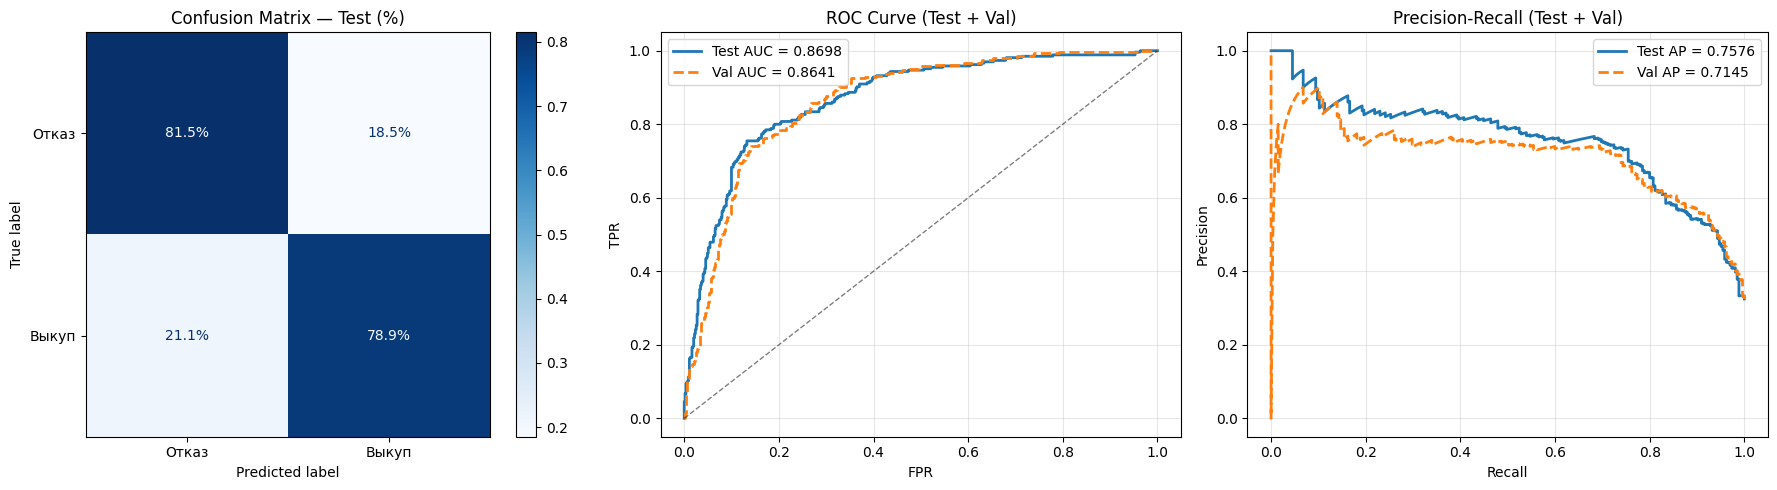

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_new_test, y_new_pred, display_labels=['Отказ', 'Выкуп'],
    normalize='true', values_format='.1%', ax=axes[0], cmap='Blues'
)
axes[0].set_title('Confusion Matrix — Test (%)')

# ROC — test + val
fpr_te, tpr_te, _ = roc_curve(y_new_test, p_new_test)
fpr_va, tpr_va, _ = roc_curve(y_new_val, p_new_val)
axes[1].plot(fpr_te, tpr_te, lw=2, label=f'Test AUC = {roc_auc_score(y_new_test, p_new_test):.4f}')
axes[1].plot(fpr_va, tpr_va, lw=2, linestyle='--', label=f'Val AUC = {roc_auc_score(y_new_val, p_new_val):.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].set_title('ROC Curve (Test + Val)'); axes[1].legend(); axes[1].grid(alpha=0.3)

# Precision-Recall
prec_te, rec_te, _ = precision_recall_curve(y_new_test, p_new_test)
prec_va, rec_va, _ = precision_recall_curve(y_new_val, p_new_val)
axes[2].plot(rec_te, prec_te, lw=2, label=f'Test AP = {average_precision_score(y_new_test, p_new_test):.4f}')
axes[2].plot(rec_va, prec_va, lw=2, linestyle='--', label=f'Val AP = {average_precision_score(y_new_val, p_new_val):.4f}')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall (Test + Val)'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

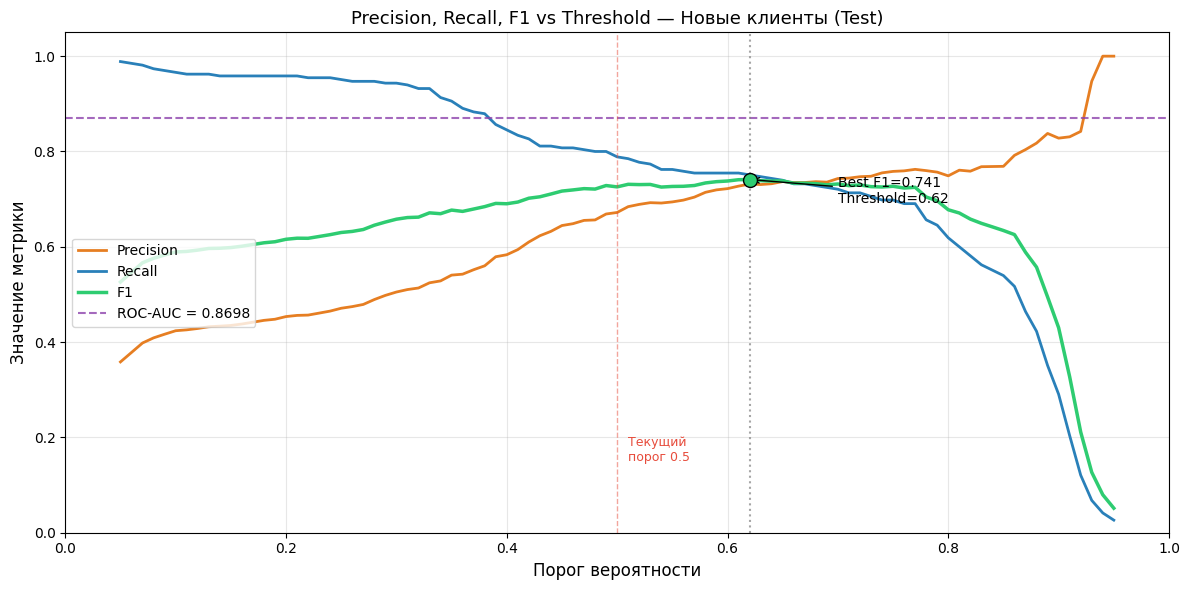

Лучший F1 = 0.7412 при пороге = 0.62
  Precision: 0.7316
  Recall:    0.7509


In [11]:
# Анализ метрик в зависимости от порога вероятности
thresholds = np.arange(0.05, 0.96, 0.01)
metrics_by_t = {'threshold': [], 'precision': [], 'recall': [], 'f1': []}

for t in thresholds:
    y_t = (p_new_test >= t).astype(int)
    if y_t.sum() == 0 or y_t.sum() == len(y_t):
        continue
    metrics_by_t['threshold'].append(t)
    metrics_by_t['precision'].append(precision_score(y_new_test, y_t, zero_division=0))
    metrics_by_t['recall'].append(recall_score(y_new_test, y_t, zero_division=0))
    metrics_by_t['f1'].append(f1_score(y_new_test, y_t, zero_division=0))

mt = pd.DataFrame(metrics_by_t)
roc_auc_val = roc_auc_score(y_new_test, p_new_test)

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(mt['threshold'], mt['precision'], color='#e67e22', lw=2, label='Precision')
ax.plot(mt['threshold'], mt['recall'], color='#2980b9', lw=2, label='Recall')
ax.plot(mt['threshold'], mt['f1'], color=GREEN, lw=2.5, label='F1')
ax.axhline(roc_auc_val, color='#8e44ad', linestyle='--', lw=1.5, alpha=0.8,
           label=f'ROC-AUC = {roc_auc_val:.4f}')

best_idx = mt['f1'].idxmax()
best_t = mt.loc[best_idx, 'threshold']
best_f1 = mt.loc[best_idx, 'f1']
ax.axvline(best_t, color='gray', linestyle=':', alpha=0.7)
ax.scatter([best_t], [best_f1], color=GREEN, s=100, zorder=5, edgecolor='black')
ax.annotate(f'Best F1={best_f1:.3f}\nThreshold={best_t:.2f}',
            xy=(best_t, best_f1), xytext=(best_t + 0.08, best_f1 - 0.05),
            fontsize=10, arrowprops=dict(arrowstyle='->', color='black'))
ax.axvline(0.5, color=RED, linestyle='--', alpha=0.5, lw=1)
ax.text(0.51, 0.15, 'Текущий\nпорог 0.5', color=RED, fontsize=9)

ax.set_xlabel('Порог вероятности', fontsize=12)
ax.set_ylabel('Значение метрики', fontsize=12)
ax.set_title('Precision, Recall, F1 vs Threshold — Новые клиенты (Test)', fontsize=13)
ax.legend(loc='center left', fontsize=10)
ax.grid(alpha=0.3); ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
plt.tight_layout(); plt.show()

print(f'Лучший F1 = {best_f1:.4f} при пороге = {best_t:.2f}')
print(f'  Precision: {mt.loc[best_idx, "precision"]:.4f}')
print(f'  Recall:    {mt.loc[best_idx, "recall"]:.4f}')

### Рекомендация по выбору порога

- Порог **0.5** — сбалансированный, текущий default
- Порог **0.62** — максимизирует F1

Выбор зависит от бизнес-приоритетов: минимизация отказов (выше порог) vs максимизация продаж (ниже порог)

## 6. Важность признаков

Encoded-признаков: 86

Все признаки по |коэффициенту|:
                                       feature    coef  abs_coef  odds_ratio
               lead_Вид оплаты_Оплата на карту  1.9076    1.9076      6.7368
                 lead_Вид оплаты_Оплата онлайн  1.5966    1.5966      4.9360
                    lead_Служба доставки_Почта  1.4649    1.4649      4.3272
             lead_responsible_user_id_MGR_0011  1.1081    1.1081      3.0287
                   lead_Служба доставки_Прочее  1.0992    1.0992      3.0017
             lead_responsible_user_id_MGR_0020  0.9484    0.9484      2.5817
             lead_responsible_user_id_MGR_0016  0.8626    0.8626      2.3694
                            mgr_group_mgr_high  0.3574    0.3574      1.4296
                lead_Квалификация лида_А - лид  0.3461    0.3461      1.4136
                                 city_clean_te  0.3297    0.3297      1.3906
             lead_responsible_user_id_MGR_0008  0.3251    0.3251      1.3842
                     

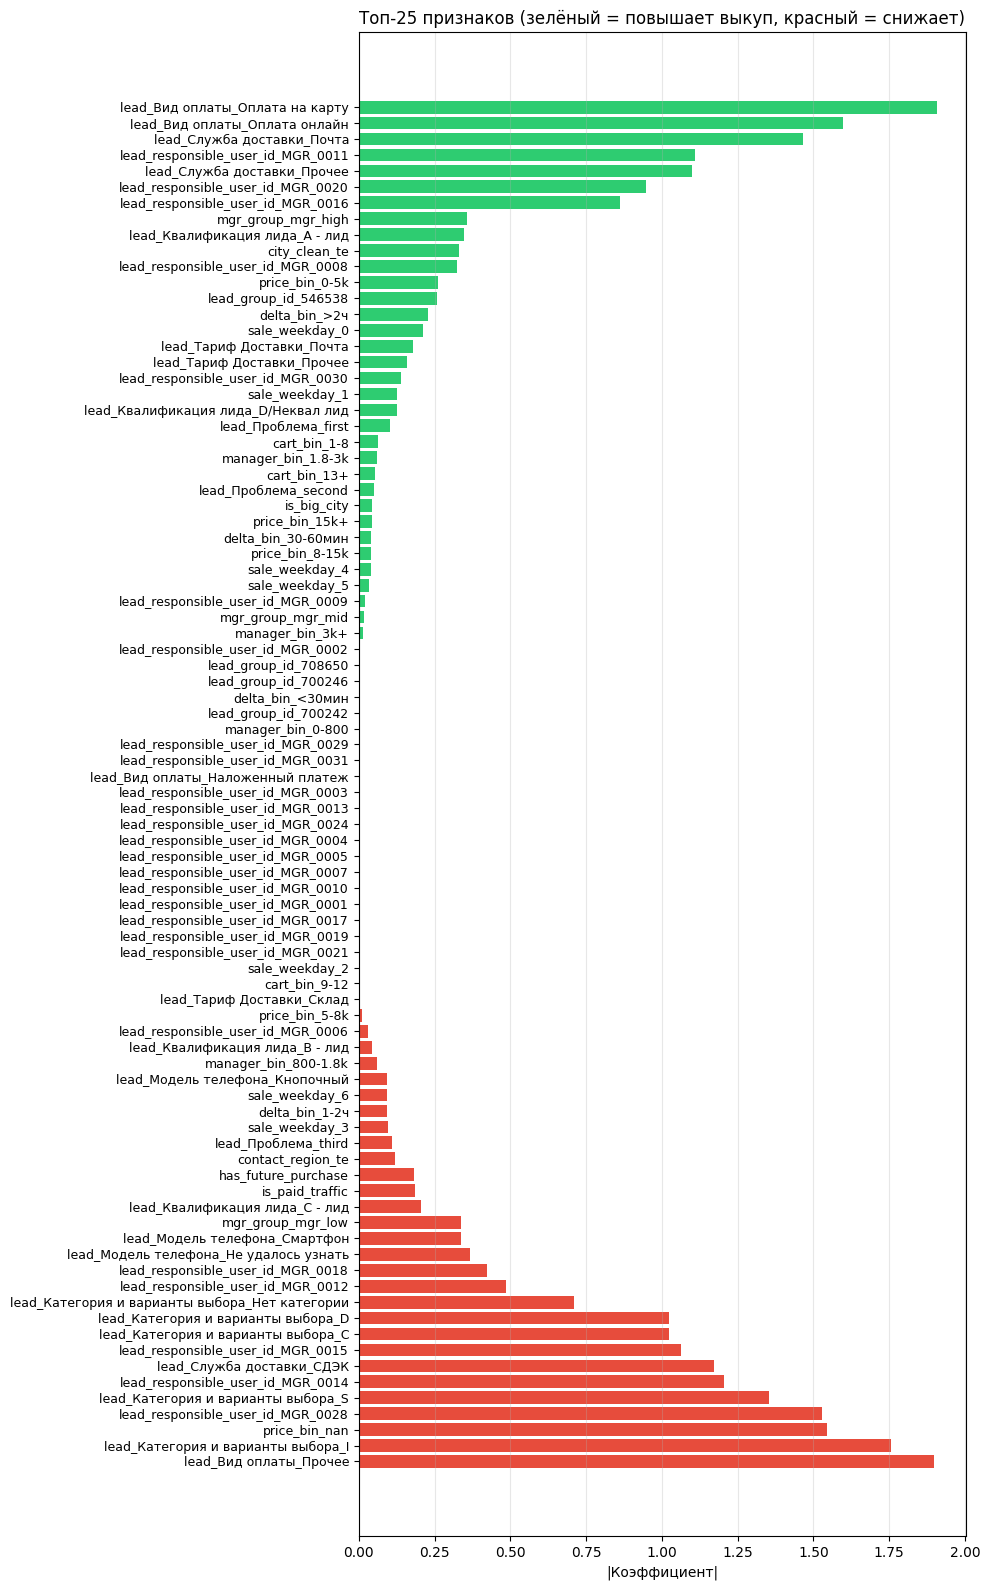

In [19]:
feat_imp = pd.DataFrame({
    'feature': X_train_enc.columns,
    'coef': model_new.coef_[0],
    'abs_coef': np.abs(model_new.coef_[0]),
    'odds_ratio': np.exp(model_new.coef_[0]),
}).sort_values('odds_ratio', ascending=False)

print(f'Encoded-признаков: {len(feat_imp)}')
print(f'\nВсе признаки по |коэффициенту|:')
print(feat_imp.to_string(index=False, float_format='%.4f'))

top25 = feat_imp.head(100).iloc[::-1]
colors = [GREEN if c > 0 else RED for c in top25['coef']]
fig, ax = plt.subplots(figsize=(10, 16))
ax.barh(range(len(top25)), top25['abs_coef'].values, color=colors)
ax.set_yticks(range(len(top25)))
ax.set_yticklabels(top25['feature'].values, fontsize=9)
ax.set_xlabel('|Коэффициент|')
ax.set_title('Топ-25 признаков (зелёный = повышает выкуп, красный = снижает)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

Важность признаков (группировка по исходным столбцам):
                                  sum_abs_coef  n_dummies  avg_abs_coef
group                                                                  
lead_responsible_user_id                8.1666         26        0.3141
lead_Категория и варианты выбора        5.8756          5        1.1751
lead_Вид оплаты                         5.3958          4        1.3490
lead_Служба доставки                    3.7199          3        1.2400
price_bin                               1.9087          5        0.3817
lead_Модель телефона                    0.8112          3        0.2704
mgr_group                               0.7611          3        0.2537
lead_Квалификация лида                  0.7167          4        0.1792
sale_weekday                            0.6052          7        0.0865
delta_bin                               0.3659          4        0.0915
lead_Тариф Доставки                     0.3217          3        0.1072
lead_Проб

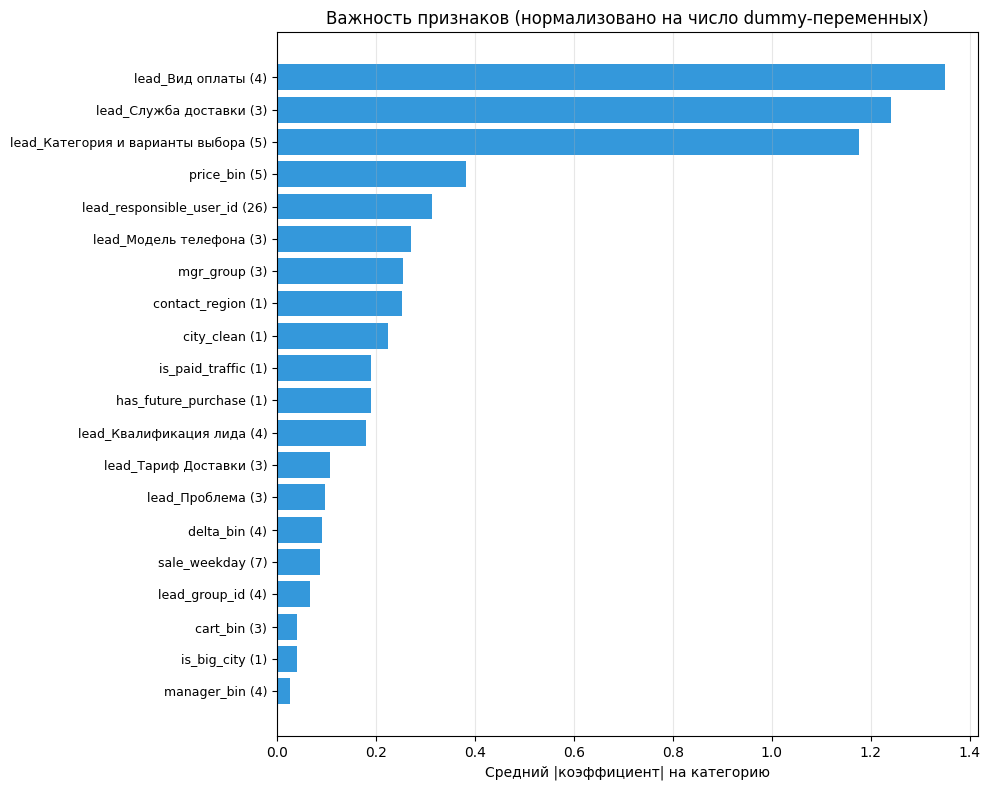

In [13]:
def get_group(col_name):
    """Определяет исходный признак по имени encoded-столбца."""
    if col_name in bin_cols or col_name in num_cols:
        return col_name
    for tc in geo_cols + te_cat_cols:
        if col_name == tc + '_te':
            return tc
    for cat in sorted(cat_cols, key=len, reverse=True):
        if col_name.startswith(cat + '_'):
            return cat
    return col_name

feat_imp['group'] = feat_imp['feature'].apply(get_group)

grouped = feat_imp.groupby('group').agg(
    sum_abs_coef=('abs_coef', 'sum'),
    n_dummies=('feature', 'count'),
).sort_values('sum_abs_coef', ascending=False)

grouped['avg_abs_coef'] = grouped['sum_abs_coef'] / grouped['n_dummies']

print('Важность признаков (группировка по исходным столбцам):')
print(grouped.to_string(float_format='%.4f'))

# Нормализованный график: средний |коэффициент| на категорию
top_g = grouped.sort_values('avg_abs_coef', ascending=False).head(100).iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 8))
labels = [f'{idx} ({int(grouped.loc[idx, "n_dummies"])})' for idx in top_g.index]
ax.barh(range(len(top_g)), top_g['avg_abs_coef'].values, color='#3498db')
ax.set_yticks(range(len(top_g)))
ax.set_yticklabels(labels, fontsize=9)
ax.set_xlabel('Средний |коэффициент| на категорию')
ax.set_title('Важность признаков (нормализовано на число dummy-переменных)')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Сохранение артефактов модели

In [14]:
# TE-маппинги из полного new_train (per-feature alpha)
te_maps = {}
global_mean = float(y_new_train.mean())

for col_te in geo_cols + te_cat_cols:
    a = TE_ALPHA_PER_FEATURE.get(col_te, TE_ALPHA)
    stats = X_new_train.join(y_new_train.rename('target')).groupby(col_te)['target'].agg(['mean', 'count'])
    te_map = (stats['mean'] * stats['count'] + global_mean * a) / (stats['count'] + a)
    te_maps[col_te] = te_map.to_dict()

# One-hot columns: per-column drop_first (mirrors training encode_fold)
oh_parts = []
for col in cat_cols:
    df_flag = cat_drop_first.get(col, False)
    oh_parts.append(pd.get_dummies(X_new_train[[col]], drop_first=df_flag))
onehot_columns = pd.concat(oh_parts, axis=1).columns.tolist()

manager_deal_count_default = int(np.median(list(manager_deal_count_map.values())))

weights = {
    'model_new': model_new,
    'model_returning': model_ret,
    'scaler_new': scaler_new,
    'scaler_returning': scaler_ret,
    'onehot_columns': onehot_columns,
    'te_maps': te_maps,
    'global_mean': global_mean,
    'cat_cols': cat_cols,
    'num_cols': num_cols,
    'bin_cols': bin_cols,
    'geo_cols': geo_cols,
    'te_cat_cols': te_cat_cols,
    'cat_drop_first': cat_drop_first,
    'russia_cities': russia_cities,
    'threshold': 0.5,
    'te_alpha': TE_ALPHA,
    'te_alpha_per_feature': TE_ALPHA_PER_FEATURE,
    'manager_deal_count_map': manager_deal_count_map,
    'manager_deal_count_default': manager_deal_count_default,
    'mgr_group_map': mgr_group_map,
    'big_city_map': big_city_map,
    # Параметры бинов для инференса (model.py)
    'cart_bins': [-1, 8, 12, float('inf')],
    'cart_labels': ['1-8', '9-12', '13+'],
    'price_bins': [0, 5000, 8000, 15000, float('inf')],
    'price_labels': ['0-5k', '5-8k', '8-15k', '15k+'],
    'delta_bins': [0, 0.5/24, 1/24, 2/24, float('inf')],
    'delta_labels': ['<30мин', '30-60мин', '1-2ч', '>2ч'],
    'manager_bins': [0, 800, 1800, 3000, float('inf')],
    'manager_labels': ['0-800', '800-1.8k', '1.8-3k', '3k+'],
}

joblib.dump(weights, 'model_weights.pkl')

size_kb = os.path.getsize('model_weights.pkl') / 1024
print(f'Сохранено model_weights.pkl ({size_kb:.0f} KB)')
print(f'  cat_cols ({len(cat_cols)}): one-hot → {len(onehot_columns)} столбцов')
print(f'  num_cols ({len(num_cols)}): ' + ('StandardScaler' if num_cols else 'нет'))
print(f'  bin_cols ({len(bin_cols)}): passthrough')
print(f'  geo_cols ({len(geo_cols)}) + te_cat_cols ({len(te_cat_cols)}): target encoding')
print(f'  TE alpha per feature: {TE_ALPHA_PER_FEATURE}')
print(f'  Модель повторных: 1 признак (contact_Число сделок)')
print(f'  Городов: {len(russia_cities)}')
print(f'  Менеджеров: {len(manager_deal_count_map)}')
print(f'  Групп менеджеров: {len(set(mgr_group_map.values()))}')

Сохранено model_weights.pkl (98 KB)
  cat_cols (15): one-hot → 81 столбцов
  num_cols (0): нет
  bin_cols (3): passthrough
  geo_cols (2) + te_cat_cols (0): target encoding
  TE alpha per feature: {'city_clean': 10, 'contact_region': 50}
  Модель повторных: 1 признак (contact_Число сделок)
  Городов: 1109
  Менеджеров: 30
  Групп менеджеров: 3


## 8. Финальная валидация на held-out данных

In [15]:
from model import BuyoutPredictor

predictor = BuyoutPredictor('model_weights.pkl')

y_val = val_df[target].values
y_val_pred = predictor.predict(val_df)
y_val_proba = predictor.predict_proba(val_df)

print('=' * 60)
print('ФИНАЛЬНАЯ ВАЛИДАЦИЯ — полный val-датасет')
print('=' * 60)
print(f'  Строк:     {len(val_df)}')
print(f'  Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}')
print(f'  F1:        {f1_score(y_val, y_val_pred):.4f}')
print(f'  ROC-AUC:   {roc_auc_score(y_val, y_val_proba):.4f}')
print(f'  Precision: {precision_score(y_val, y_val_pred):.4f}')
print(f'  Recall:    {recall_score(y_val, y_val_pred):.4f}')
print(f'  MCC:       {matthews_corrcoef(y_val, y_val_pred):.4f}')
print('=' * 60)

is_new_val = val_df['contact_Число сделок'].isna() | (val_df['contact_Число сделок'] < 1)

for label, mask in [('Новые клиенты', is_new_val), ('Повторные клиенты', ~is_new_val)]:
    idx = mask.values
    if idx.sum() == 0:
        continue
    y_sub = y_val[idx]
    p_sub = y_val_pred[idx]
    pr_sub = y_val_proba[idx]
    print(f'\n  {label} (N={idx.sum()}):')
    print(f'    Accuracy:  {accuracy_score(y_sub, p_sub):.4f}')
    print(f'    F1:        {f1_score(y_sub, p_sub):.4f}')
    print(f'    ROC-AUC:   {roc_auc_score(y_sub, pr_sub):.4f}')
    print(f'    Precision: {precision_score(y_sub, p_sub):.4f}')
    print(f'    Recall:    {recall_score(y_sub, p_sub):.4f}')

ФИНАЛЬНАЯ ВАЛИДАЦИЯ — полный val-датасет
  Строк:     3593
  Accuracy:  0.9377
  F1:        0.9629
  ROC-AUC:   0.8746
  Precision: 0.9485
  Recall:    0.9778
  MCC:       0.7706

  Новые клиенты (N=816):
    Accuracy:  0.8064
    F1:        0.7158
    ROC-AUC:   0.8641
    Precision: 0.6838
    Recall:    0.7509

  Повторные клиенты (N=2777):
    Accuracy:  0.9762
    F1:        0.9880
    ROC-AUC:   0.5000
    Precision: 0.9762
    Recall:    1.0000


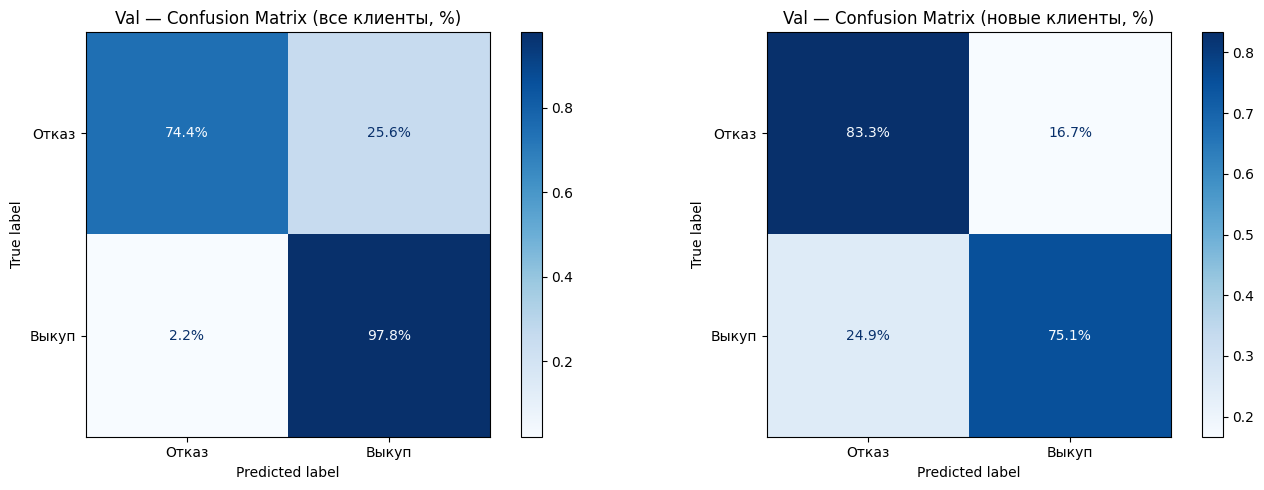


Валидация завершена.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val, y_val_pred, display_labels=['Отказ', 'Выкуп'],
    normalize='true', values_format='.1%', ax=axes[0], cmap='Blues'
)
axes[0].set_title('Val — Confusion Matrix (все клиенты, %)')

y_new_val_actual = y_val[is_new_val.values]
y_new_val_pred_actual = y_val_pred[is_new_val.values]

ConfusionMatrixDisplay.from_predictions(
    y_new_val_actual, y_new_val_pred_actual, display_labels=['Отказ', 'Выкуп'],
    normalize='true', values_format='.1%', ax=axes[1], cmap='Blues'
)
axes[1].set_title('Val — Confusion Matrix (новые клиенты, %)')

plt.tight_layout(); plt.show()
print('\nВалидация завершена.')